# Scikit-learn PCA 實作

PCA 做的事像這樣：

先找一條「最重要的線」
這條線的方向是：
資料沿著它分散得最開（變異最大）
也就是「最能看出差異」的方向。
這條線叫 第一主成分（PC1）。

把每個點「打到這條線上」（投影）
你原本每個點有很多特徵（很多維），
投影後，你只要記得它在線上的位置（1 個數字）就好。
→ 多維變 1 維

如果你要保留更多資訊
再找第二條方向（PC2）：

它也要讓變異大

但不能跟第一條重複（要垂直/獨立）
然後投影到 PC1 + PC2 平面上
→ 多維變 2 維

In [17]:
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
ds = datasets.load_wine()
df = pd.DataFrame(ds.data,columns=ds.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X = df.values
y = ds.target
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((124, 13), (54, 13), (124,), (54,))

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std =  scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


In [ ]:
df.info()

## 特徵萃取(PCA)

In [21]:
from sklearn.decomposition import PCA
pcal = PCA(n_components=2)
X_train_pca = pcal.fit_transform(X_train_std)
X_test_pca = pcal.transform(X_test_std)
X_train_pca.shape,X_test_pca.shape

((124, 2), (54, 2))

In [22]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_std,y_train)

LogisticRegression()

## 無PCA

In [23]:
y_pred = clf.predict(X_test_std)
print(f"Accuracy:{accuracy_score(y_test,y_pred)}")

Accuracy:0.9629629629629629


## 使用PCA

In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_pca,y_train)

LogisticRegression()

In [29]:
y_pred_pca = clf.predict(X_test_pca)
print(f"PCA Accuracy:{accuracy_score(y_test,y_pred_pca):.2f}")

PCA Accuracy:0.94


## 特徵萃取(KernelPCA)

In [37]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std =  scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

kpca = KernelPCA(n_components=2,kernel='rbf',gamma=10)
X_train_kpca = kpca.fit_transform(X_train_std)
X_test_kpca = kpca.transform(X_test_std)
print(X_train_kpca.shape,X_test_kpca.shape)

clf = LogisticRegression()
clf.fit(X_train_kpca,y_train)
y_pred = clf.predict(X_test_kpca)
print(f"KPCA Accuracy:{accuracy_score(y_test,y_pred):.2f}")


(124, 2) (54, 2)
KPCA Accuracy:0.37


In [35]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
best = (-1,None)

for g in [0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50]:
    kpca = KernelPCA(n_components=2,kernel='rbf',gamma=g)
    X_train_kpca = kpca.fit_transform(X_train_std)
    X_test_kpca = kpca.transform(X_test_std)
    clf = LogisticRegression()
    clf.fit(X_train_kpca,y_train)
    y_pred = clf.predict(X_test_kpca)
    acc = accuracy_score(y_test,y_pred)
    print(f"gamma={g},Accuracy={acc}")
    if acc > best[0]:
        best = (acc,g)

print(f"best: {best}")

gamma=0.01,Accuracy=0.9074074074074074
gamma=0.05,Accuracy=0.9259259259259259
gamma=0.1,Accuracy=0.9074074074074074
gamma=0.2,Accuracy=0.8518518518518519
gamma=0.5,Accuracy=0.6111111111111112
gamma=1,Accuracy=0.3888888888888889
gamma=2,Accuracy=0.37037037037037035
gamma=5,Accuracy=0.37037037037037035
gamma=10,Accuracy=0.37037037037037035
gamma=20,Accuracy=0.37037037037037035
gamma=50,Accuracy=0.37037037037037035
best: (0.9259259259259259, 0.05)


In [42]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
best = (-1, None)
try:
    for g in [0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50]:
        kpca = KernelPCA(n_components=2, kernel="rbf", gamma=g,
                         eigen_solver="arpack", remove_zero_eig=True)
        X_train_kpca = kpca.fit_transform(X_train_std)
        X_test_kpca = kpca.transform(X_test_std)
        clf = LogisticRegression()
        clf.fit(X_train_kpca, y_train)
        y_pred = clf.predict(X_test_kpca) 
        acc = accuracy_score(y_test, y_pred)
        print(f"gamma={g}, Accuracy={acc}")
        if acc > best[0]:
            best = (acc, g)
except:
    pass

print(f"best: {best}")

gamma=0.01, Accuracy=0.9074074074074074
gamma=0.05, Accuracy=0.9259259259259259
gamma=0.1, Accuracy=0.9074074074074074
gamma=0.2, Accuracy=0.8518518518518519
gamma=0.5, Accuracy=0.6111111111111112
gamma=1, Accuracy=0.3888888888888889
gamma=2, Accuracy=0.37037037037037035
gamma=5, Accuracy=0.37037037037037035
gamma=10, Accuracy=0.37037037037037035
gamma=20, Accuracy=0.37037037037037035
gamma=50, Accuracy=0.37037037037037035
best: (0.9259259259259259, 0.05)


# Scikit-learn LDA實作
它找一條（或幾條）線，讓不同類別的人在投影後分得最開、同一類的人聚得最緊。

In [43]:
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ds = datasets.load_wine()
df = pd.DataFrame(ds.data, columns=ds.feature_names)
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 指定X、Y
X = df.values
y = ds.target

# 資料分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

# 查看陣列維度
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [46]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std,y_train)
X_test_lda = lda.transform(X_test_std)
X_train_lda.shape, X_test_lda.shape

((142, 2), (36, 2))

In [47]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_lda,y_train)
y_pred = clf.predict(X_test_lda)
acc = accuracy_score(y_test,y_pred)
print(f"Accuracy={acc}")

Accuracy=1.0


# 簡單線性回歸導論

簡單線性回歸的核心公式是找到最佳擬合直線，即所謂的回歸線，其公式可以表示為：

$ y = \beta_0 + \beta_1 x $

其中：
- $ y $ 是應變量（依賴變量）。
- $ x $ 是自變量（獨立變量）。
- $ \beta_0 $ 是截距，即直線在 $ y $ 軸的交點。
- $ \beta_1 $ 是斜率，表示 $ x $ 變動一單位時 $ y $ 的變動量。

### 參數估計
使用最小二乘法來估計 $ \beta_0 $ 和 $ \beta_1 $，計算公式如下：

$ \beta_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} $

$ \beta_0 = \bar{y} - \beta_1 \bar{x} $

其中：
- $ \bar{x} $ 和 $ \bar{y} $ 分別是 $ x $ 和 $ y $ 的平均值。
- $ n $ 是數據點的數量。

### 計算範例
假設我們有以下的數據點：

| $ x $ (年經驗) | $ y $ (年薪，單位：萬元) |
|---------|------------------|
| 1       | 3                |
| 2       | 4                |
| 3       | 5                |
| 4       | 6                |

我們要找到這些數據的線性回歸方程。首先計算 $ x $ 和 $ y $ 的平均值：

$[\bar{x} = \frac{1 + 2 + 3 + 4}{4} = 2.5]$

$ \bar{y} = \frac{3 + 4 + 5 + 6}{4} = 4.5 $

接下來計算斜率 $ \beta_1 $：

$ \beta_1 = \frac{(1-2.5)(3-4.5) + (2-2.5)(4-4.5) + (3-2.5)(5-4.5) + (4-2.5)(6-4.5)}{(1-2.5)^2 + (2-2.5)^2 + (3-2.5)^2 + (4-2.5)^2} = \frac{(-1.5)(-1.5) + (-0.5)(-0.5) + (0.5)(0.5) + (1.5)(1.5)}{2.5} = 1 $

計算截距 $ \beta_0 $：

$ \beta_0 = 4.5 - 1 \times 2.5 = 2 $

因此，回歸方程為：

$ y = 2 + 1x $

或簡化為：

$ y = 2 + x $

這樣，給定任何 $ x $ 的值，我們都可以使用這個方程來預測 $ y $ 的值。例如，若一人具有 5 年的經驗，其年薪預估為：

$ y = 2 + 5 = 7 $（單位：萬元）



In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [50]:
df["total_spend"] = df["TV"] + df["radio"] + df["newspaper"]


<Axes: xlabel='total_spend', ylabel='sales'>

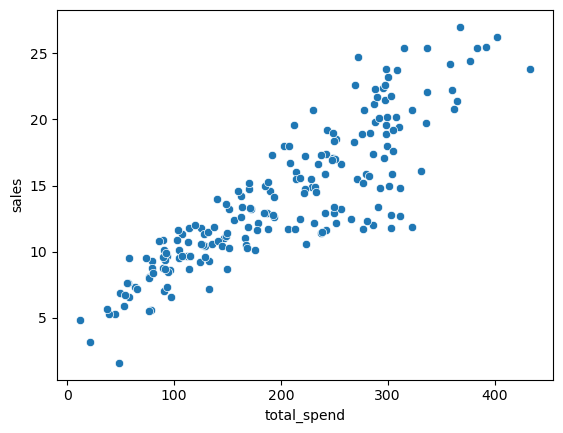

In [51]:
sns.scatterplot(x="total_spend",y="sales",data=df)


$ y = \beta_0 + \beta_1 x $

其中：
- $ y $ 是應變量（依賴變量）。
- $ x $ 是自變量（獨立變量）。
- $ \beta_0 $ 是截距，即直線在 $ y $ 軸的交點。
- $ \beta_1 $ 是斜率，表示 $ x $ 變動一單位時 $ y $ 的變動量。

### 參數估計
使用最小二乘法來估計 $ \beta_0 $ 和 $ \beta_1 $，計算公式如下：

$ \beta_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} $

$ \beta_0 = \bar{y} - \beta_1 \bar{x} $

其中：
- $ \bar{x} $ 和 $ \bar{y} $ 分別是 $ x $ 和 $ y $ 的平均值。
- $ n $ 是數據點的數量。

In [53]:
x = df["total_spend"]
y = df["sales"]

x_mean = np.mean(x)
y_mean = np.mean(y)
beta_1 = np.sum((x - x_mean) * (y - y_mean) ) / np.sum((x - x_mean) ** 2)
beta_0 = y_mean - beta_1 * x_mean
print(f"y={beta_0:.2f}+{beta_1:.2f}x")


y=4.24+0.05x


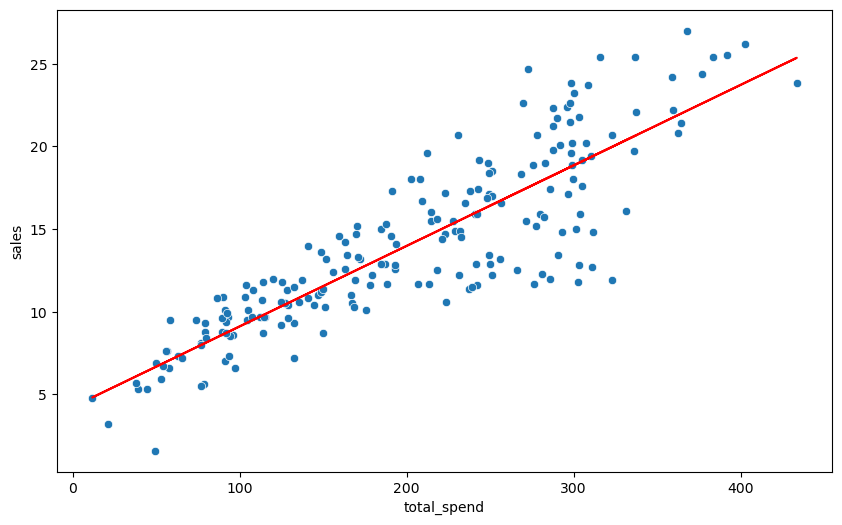

In [68]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="total_spend",y="sales",data=df)
plt.plot(x,beta_0 + beta_1 *x,c="red")

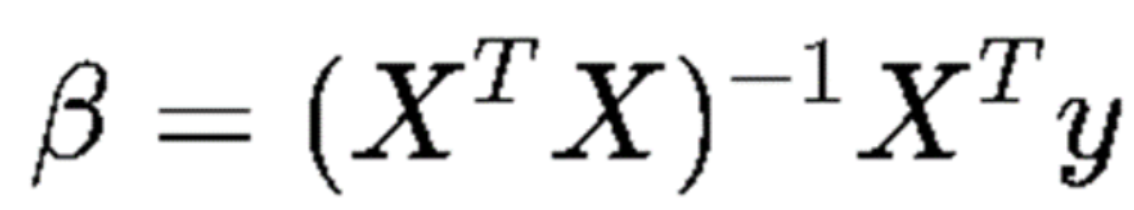

w[0,0] = β₁（斜率），

w[1,0] = β₀（截距）。

In [69]:
import numpy as np


In [86]:
year=[1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020]
pop=[2.53, 2.57, 2.62, 2.67, 2.71, 2.76, 2.81, 2.86, 2.92, 2.97, 3.03,
       3.08, 3.14, 3.2 , 3.26, 3.33, 3.4 , 3.47, 3.54, 3.62, 3.69, 3.77,
       3.84, 3.92, 4.  , 4.07, 4.15, 4.22, 4.3 , 4.37, 4.45, 4.53, 4.61,
       4.69, 4.78, 4.86, 4.95, 5.05, 5.14, 5.23, 5.32, 5.41, 5.49, 5.58,
       5.66, 5.74, 5.82, 5.9 , 5.98, 6.05, 6.13, 6.2 , 6.28, 6.36, 6.44,
       6.51, 6.59, 6.67, 6.75, 6.83, 6.92, 7.  , 7.08, 7.16, 7.24, 7.32,
       7.4 , 7.48, 7.56, 7.64, 7.72]

In [87]:
X = np.array(year).reshape(-1,1)
y = np.array(pop).reshape(-1,1)
X.shape,y.shape

((71, 1), (71, 1))

In [88]:
one = np.ones((X.shape[0],1))

In [89]:
X = np.concatenate((X,one),axis=1)
X[:5]

array([[1.950e+03, 1.000e+00],
       [1.951e+03, 1.000e+00],
       [1.952e+03, 1.000e+00],
       [1.953e+03, 1.000e+00],
       [1.954e+03, 1.000e+00]])

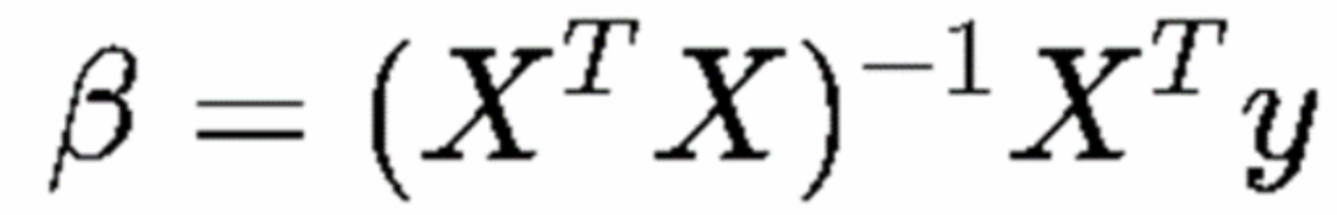

In [90]:
w = np.linalg.inv(X.T@X)@X.T@y
w

array([[ 7.72102616e-02],
       [-1.48313919e+02]])